# Chapter 5: Model Evaluation and Improvement

We will focus on supervised models (regression & classification) as evaluating unsupervised learning is often a very qualitative process

In this chapter, we will go over **cross-validation**, a robust way to assess generalization performance, and other methods such as **grid search**

In [1]:
# create an environment where we can import all the needed modules
import sys, os
sys.path.append('../introduction_to_ml_with_python')
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
import mglearn

In [2]:
# just to illustrate what we have been doing so far
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x, y = make_blobs(random_state=0)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=0)
logreg = LogisticRegression().fit(xtrain, ytrain)
print("Test set score: {:.2f}".format(logreg.score(xtest, ytest)))

Test set score: 0.88


## Cross-Validation

**Cross-validation** is a statistical method of evaluating generalization performance that is more stable and thorough than using a split into a training and test set. In this approach, the data is instead split repeatedly and multiple modles are trained.

The most commonly used version of cross-validation is **k-fold cross-validation**, where the data is first partitioned into *k* parts of (approximately) equal size called *folds*. Next, a sequence of models is trained. The first model is trained using the first fold as the test set, and the remaining folds are used as the training set. Another model is then built, setting the second fold as the test while the rest remain as the training set, and the process continues on.

In [3]:
# practice cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris   = load_iris()
logreg = LogisticRegression()
scores = cross_val_score(logreg, iris.data, iris.target) # default is 5 splits
print(scores)

[0.96666667 1.         0.93333333 0.96666667 1.        ]


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
# do 3 splits
scores = cross_val_score(logreg, iris.data, iris.target, cv=3)
print(scores)

[0.98 0.96 0.98]


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
# A common way to summarize the accuracy is by computing the mean
print(scores.mean())

0.9733333333333333


There are several benefits to using cross-validation instead of a single split. First, splitting is done at random. Imagine that we get "lucky" when randomly splitting, and all hard examples are in the training set. In that case, the test will only contain "easy" examples. Conversely, if we are "unlucky" we might have randomly put all the hard examples in the test set and all the easy examples in the training set.

Having multiple splits of the data also provides some information about how senstive our model is to the selection of the training dataset. Also, more folds means using $\frac{N-1}{N}$ as training and $\frac{1}{N}$ as test sets.

In [6]:
#
# splitting the data into k folds is not always a good idea
#
print(iris.target) # see how the data is not randomly distributed

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


## Stratified k-Fold Cross-Validation and Other Strategies
In **stratified k-fold cross validation**, we split the data such that the proportions between the classes are the same in each fold as they are in the whole dataset

We can also control the parameters of the splitting ourselves

In [7]:
from sklearn.model_selection import KFold

kFold = KFold(n_splits=5)
print(cross_val_score(logreg, iris.data, iris.target, cv = kFold))

kFold = KFold(n_splits=3)
print(cross_val_score(logreg, iris.data, iris.target, cv = kFold))

[1.         1.         0.86666667 0.93333333 0.83333333]
[0. 0. 0.]


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

In [8]:
# we may need to shuffle the points around
kFold = KFold(n_splits=3, shuffle=True, random_state=0)
print(cross_val_score(logreg, iris.data, iris.target, cv = kFold))

[0.98 0.96 0.96]


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

Another approach is to use the **leave-one-out** approach, where each fold is a single sample. So instead of folds representing sections of data, each fold is a data point.

In [9]:
from sklearn.model_selection import LeaveOneOut

loo    = LeaveOneOut()
scores = cross_val_score(logreg, iris.data, iris.target, cv=loo)
print("Number of iterations:", len(scores), "and mean", scores.mean())

/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

Number of iterations: 150 and mean 0.9666666666666667


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

In **shuffle-split**, each split samples *train size* many points for training sets and *test size* points for test sets. It is repeated *n* times

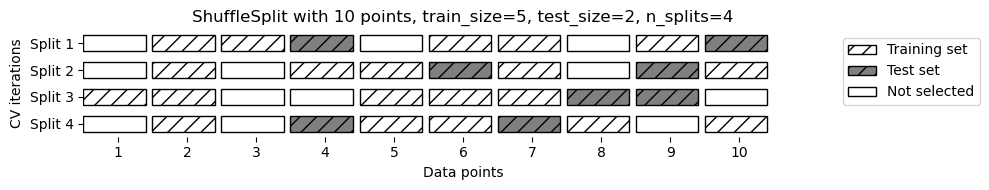

In [10]:
mglearn.plots.plot_shuffle_split()

In [11]:
from sklearn.model_selection import ShuffleSplit

shuffle_split = ShuffleSplit(test_size=.5, train_size=.5, n_splits=10)
scores        = cross_val_score(logreg, iris.data, iris.target, cv = shuffle_split)
print(scores)

[0.97333333 0.96       0.96       0.96       0.97333333 0.96
 1.         0.93333333 0.94666667 0.96      ]


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

We can also stratify/split using *groups*.

In [12]:
from sklearn.model_selection import GroupKFold

x, y   = make_blobs(n_samples=12, random_state=0)
groups = [0, 0, 0, 1, 1, 1, 1, 2, 2, 3, 3, 3] # since we have 3 per group
scores = cross_val_score(logreg, x, y, groups=groups, cv = GroupKFold(n_splits=3))
print(scores)

[0.75       0.6        0.66666667]


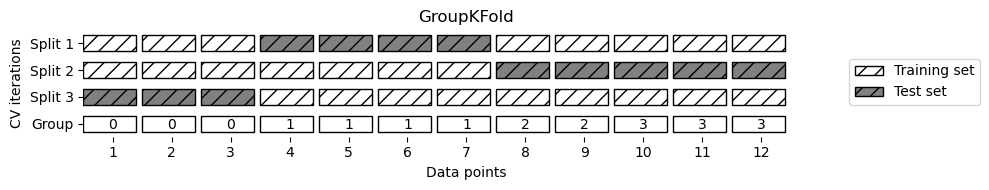

In [13]:
# visualize
mglearn.plots.plot_group_kfold()

## Grid Search

Finding the values of the important parameters of a model (the ones that provide the best generalization performance) is a tricky task, but necessary for almost all models and datasets. *Grid search* basically means trying all possible combinations of parameters of interest

In [14]:
#
# illustrate what this would look like if
# done manually
#

from sklearn.svm import SVC

xtrain, xtest, ytrain, ytest = train_test_split(iris.data, iris.target, random_state=0)

print("Size of training set: {} size of test set: {}".format(xtrain.shape[0], xtest.shape[0]))
best_score      = 0
best_parameters = {}

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for c in [0.001, 0.01, 0.1, 1, 10, 100]:
    # for each combination of parameters, train an SVC
        svm = SVC(gamma=gamma, C=c)
        svm.fit(xtrain, ytrain)
        # evaluate the SVC on the test set
        score = svm.score(xtest, ytest)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': c, 'gamma': gamma}

print("Best score: {:.2f}".format(best_score))
print("Best parameters: {}".format(best_parameters))

Size of training set: 112 size of test set: 38
Best score: 0.97
Best parameters: {'C': 100, 'gamma': 0.001}


The approach implemented above is wrong and bad. We used the test data set to adjust the parameters of the model and not the train dataset.

One way to resolve this problem is to split the data again, so we have three data sets: the training set to build the model, the validation (or development) set to select the parameters of the model, and the test set to evaluate the performance of the selected parameters

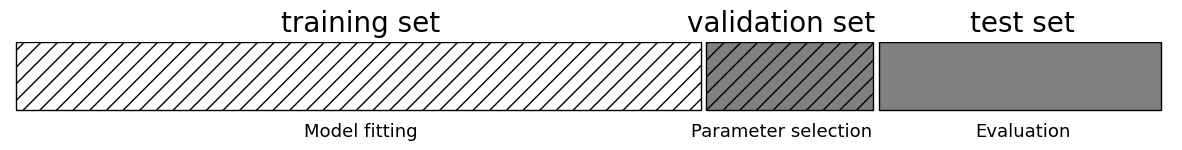

In [15]:
mglearn.plots.plot_threefold_split()

In [16]:
# do a normal split
xtrainval, Xtest, ytrainval, ytest = train_test_split(iris.data, iris.target, random_state=0)

# do a secondary split
xtrain, xvalid, ytrain, yvalid = train_test_split(xtrainval, ytrainval, random_state=1)

print("Size of training set: {} size of validation set: {} size of test set:"" {}\n".format(xtrain.shape[0], xvalid.shape[0], xtest.shape[0]))

best_score      = 0
best_parameters = {}

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for c in [0.001, 0.01, 0.1, 1, 10, 100]:
        # for each combination of parameters, train an SVC
        svm = SVC(gamma=gamma, C=c)
        svm.fit(xtrain, ytrain)
        # evaluate the SVC on the test set
        score = svm.score(xvalid, yvalid)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': c, 'gamma': gamma}

# rebuild a model on the combined training and validation set,
# and evaluate it on the test set
svm = SVC(**best_parameters)
svm.fit(xtrainval, ytrainval)
test_score = svm.score(xtest, ytest)
print("Best score on validation set: {:.2f}".format(best_score))
print("Best parameters: ", best_parameters)
print("Test set score with best parameters: {:.2f}".format(test_score))

Size of training set: 84 size of validation set: 28 size of test set: 38

Best score on validation set: 0.96
Best parameters:  {'C': 10, 'gamma': 0.001}
Test set score with best parameters: 0.92


What we did was prevent the test set from "leaking" information to the model to improve its accuracy

In [20]:
#
# GRID SEARCH WITH CROSS-VALIDATION
import numpy as np

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for c in [0.001, 0.01, 0.1, 1, 10, 100]:
        # for each combination of parameters,
        # train an SVC
        svm = SVC(gamma=gamma, C=c)
        # perform cross-validation
        scores = cross_val_score(svm, xtrainval, ytrainval, cv=5)
        # compute mean cross-validation accuracy
        score = np.mean(scores)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': c, 'gamma': gamma}
# rebuild a model on the combined training and validation set
svm = SVC(**best_parameters)
svm.fit(xtrainval, ytrainval)


SVC(C=10, gamma=0.1)

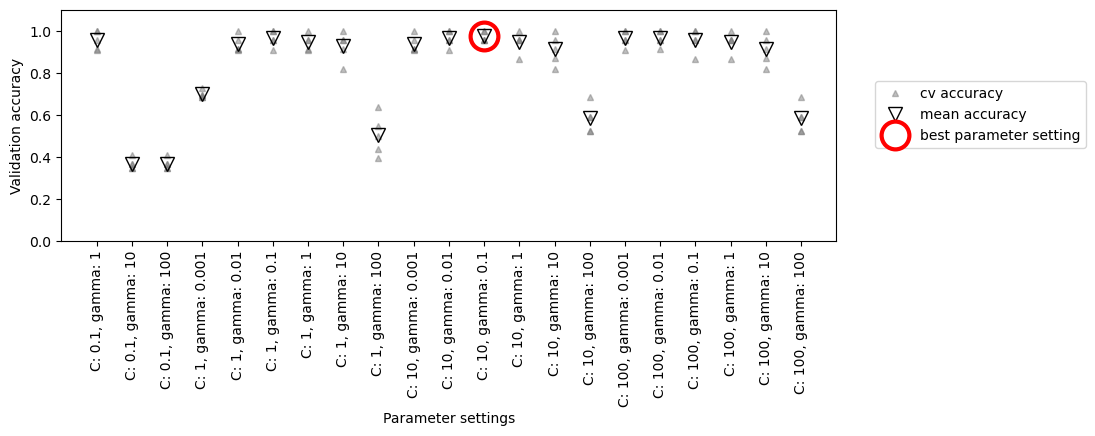

In [24]:
# illustrate our model selected
mglearn.plots.plot_cross_val_selection()

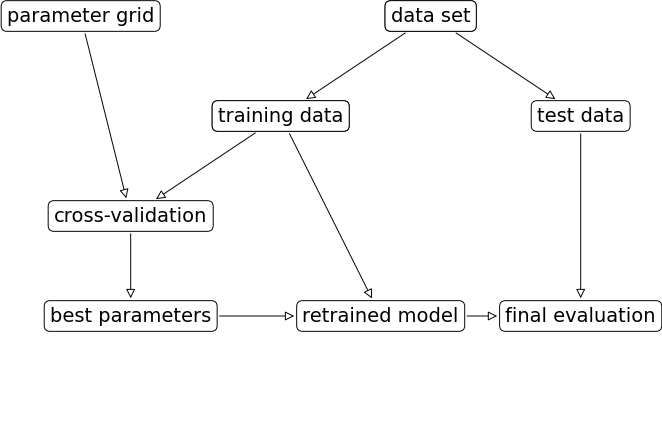

In [21]:
# illustrate what we did above
mglearn.plots.plot_grid_search_overview()

In [ ]:
# using the grid search utility
from sklearn.model_selection import GridSearchCV

#
# construct a dict
# of parameter -> list of values
#
param_grid  = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
               'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(SVC(), param_grid=param_grid, cv=5)

xtrain, xtest, ytrain, ytest = train_test_split(iris.data, iris.target, random_state=0)

# it will run cross validation of 5 splits
grid_search.fit(xtrain, ytrain) 

# will end up fitting with the best model
grid_search.score(xtest, ytest)


# this is better because we DID NOT use the test set to just the model

0.9736842105263158

In [26]:
# access the best models parameters
print(grid_search.best_params_, grid_search.best_score_)

{'C': 10, 'gamma': 0.1} 0.9731225296442687


In [28]:
# look at the coefficients
print(grid_search.best_estimator_)

SVC(C=10, gamma=0.1)


In [29]:
# let's look at how the different parameters faired in the grid search
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)
display(results.head())

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000549,0.000092,0.000270,0.000034,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
1,0.000482,0.000065,0.000312,0.000159,0.001,0.01,"{'C': 0.001, 'gamma': 0.01}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
2,0.000453,0.000072,0.000453,0.000452,0.001,0.1,"{'C': 0.001, 'gamma': 0.1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
3,0.000493,0.000047,0.000246,0.000016,0.001,1,"{'C': 0.001, 'gamma': 1}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22
4,0.000528,0.000086,0.000258,0.000038,0.001,10,"{'C': 0.001, 'gamma': 10}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,22


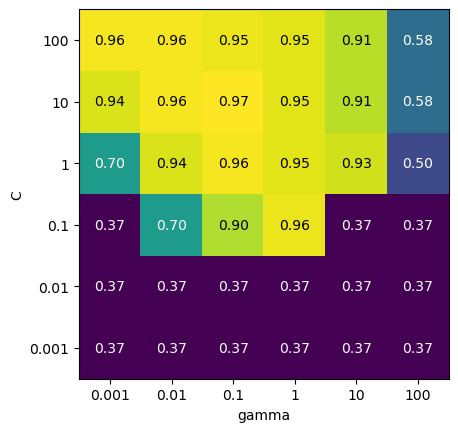

In [30]:
# see the scores
scores = np.array(results.mean_test_score).reshape(6, 6)

# plot the mean cross-validation scores
mglearn.tools.heatmap(scores, xlabel='gamma', xticklabels=param_grid['gamma'], ylabel='C', yticklabels=param_grid['C'], cmap="viridis")

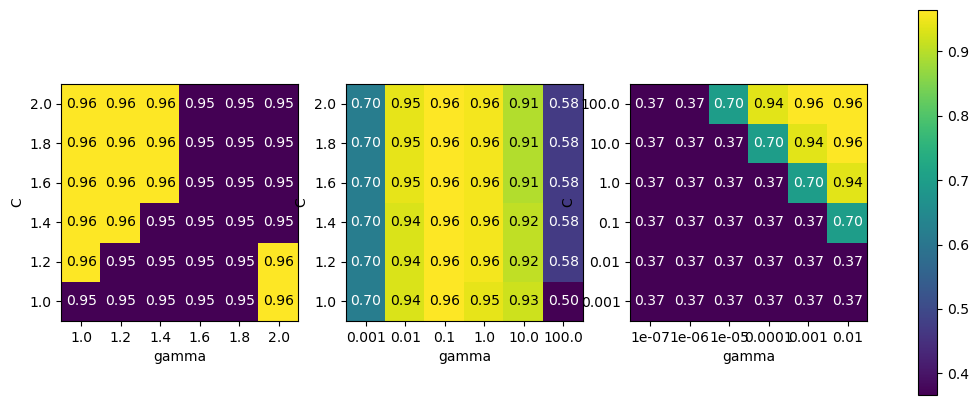

In [31]:
# visualize what it looks like to not choose parameter values wisely
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

param_grid_linear = {'C': np.linspace(1, 2, 6), 'gamma': np.linspace(1, 2, 6)}
param_grid_one_log = {'C': np.linspace(1, 2, 6), 'gamma': np.logspace(-3, 2, 6)}
param_grid_range = {'C': np.logspace(-3, 2, 6), 'gamma': np.logspace(-7, -2, 6)}

for param_grid, ax in zip([param_grid_linear, param_grid_one_log, param_grid_range], axes):
    grid_search = GridSearchCV(SVC(), param_grid, cv=5)
    grid_search.fit(xtrain, ytrain)
    scores = grid_search.cv_results_['mean_test_score'].reshape(6, 6)
    # plot the mean cross-validation scores
    scores_image = mglearn.tools.heatmap(scores, xlabel='gamma', ylabel='C', xticklabels=param_grid['gamma'], yticklabels=param_grid['C'], cmap="viridis", ax=ax)

plt.colorbar(scores_image, ax=axes.tolist())

In [32]:
# you can also feed this utility different sets of parameter combinations to try
# i.e., multiple dictionaries which can be used with different models

param_grid = [{'kernel': ['rbf'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]},
              {'kernel': ['linear'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}]

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(xtrain, ytrain)
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.97


In [33]:
results = pd.DataFrame(grid_search.cv_results_)
display(results.head())

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000766,0.000194,0.000521,0.000325,0.001,0.001,rbf,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,27
1,0.000606,0.000143,0.000294,0.000063,0.001,0.01,rbf,"{'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,27
2,0.000420,0.000037,0.000263,0.000095,0.001,0.1,rbf,"{'C': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,27
3,0.000528,0.000055,0.000318,0.000123,0.001,1,rbf,"{'C': 0.001, 'gamma': 1, 'kernel': 'rbf'}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,27
4,0.000508,0.000045,0.000262,0.000046,0.001,10,rbf,"{'C': 0.001, 'gamma': 10, 'kernel': 'rbf'}",0.347826,0.347826,0.363636,0.363636,0.409091,0.366403,0.022485,27


In [ ]:
# stopped on page 272 in the book